<a href="https://colab.research.google.com/github/ag22042008/data-Science-notebooks/blob/main/project1indeeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df=pd.read_csv('/content/Churn_Modelling.csv')

In [58]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [59]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [63]:
X=df.drop(['Exited'],axis=1)

In [64]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [65]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [66]:
X.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [67]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [68]:
X=pd.get_dummies(X,columns=['Geography','Gender'],drop_first=True)
#we can show the deleted categories like france with 0 germany 0 spain similarly 0 male 1 female

In [69]:
from sklearn.model_selection import train_test_split
Y=df['Exited']
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [70]:
X_train.shape

(8000, 11)

In [71]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [72]:
X_train=pd.DataFrame(X_train,columns=X.columns)

In [73]:
X_test=pd.DataFrame(X_test,columns=X.columns)

In [74]:
import tensorflow as tf
from tensorflow import keras

In [75]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [76]:

model=Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(3,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [77]:
model.summary() #40- 36 FROM 3*11 IMPUTS +3 BIASES AND 4 FROM 1*3+1 BIASES

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [79]:
 history=model.fit(X_train,y_train,epochs=100,validation_split=0.2)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5936 - loss: 0.6967 - val_accuracy: 0.7925 - val_loss: 0.6415
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7931 - loss: 0.5871 - val_accuracy: 0.7987 - val_loss: 0.5208
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7934 - loss: 0.4979 - val_accuracy: 0.7987 - val_loss: 0.4734
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7936 - loss: 0.4746 - val_accuracy: 0.7994 - val_loss: 0.4572
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7961 - loss: 0.4625 - val_accuracy: 0.8037 - val_loss: 0.4469
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7970 - loss: 0.4535 - val_accuracy: 0.8062 - val_loss: 0.4405
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8005 - loss: 0.4464 - val_accuracy: 0.8094 - val_loss: 0.4353
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8028 - loss: 0.4408 - va

In [80]:
model.layers[0].get_weights()# last array biases #1 array weights calculated

[array([[-0.06121837,  0.01006675, -0.01994912],
        [-0.33051038, -1.0538579 , -0.25801829],
        [-0.09936135, -0.05326759, -0.06109718],
        [ 0.40561667, -0.05793232, -0.3164339 ],
        [ 1.12989   ,  0.16520028, -0.9560522 ],
        [-0.1627372 , -0.09208943, -0.07446227],
        [-0.48081315, -0.52179396, -0.87741584],
        [ 0.02250747,  0.01886096,  0.02484607],
        [-0.12872846, -0.00360761,  0.3744891 ],
        [ 0.03501854, -0.06171115, -0.04136458],
        [-0.13149336,  0.05528112, -0.0872933 ]], dtype=float32),
 array([-0.20005323,  1.4650615 ,  1.1178583 ], dtype=float32)]

In [81]:
model.layers[1].get_weights()

[array([[-0.78746814,  1.3146741 , -0.7097689 , -0.45425802],
        [ 1.3844076 , -0.29931605, -0.8047047 ,  0.21556236],
        [-0.3832603 , -0.9757069 , -0.7376925 ,  0.9280336 ]],
       dtype=float32),
 array([ 0.962003  , -0.2007281 ,  0.        , -0.00724346], dtype=float32)]

In [82]:
y_log=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [83]:
y_pred=np.where(y_log>0.5,1,0)

In [84]:
from sklearn.metrics import accuracy_score

In [85]:
accuracy_score(y_test,y_pred)

0.8625

In [86]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Text(0.5, 0, 'epoch')

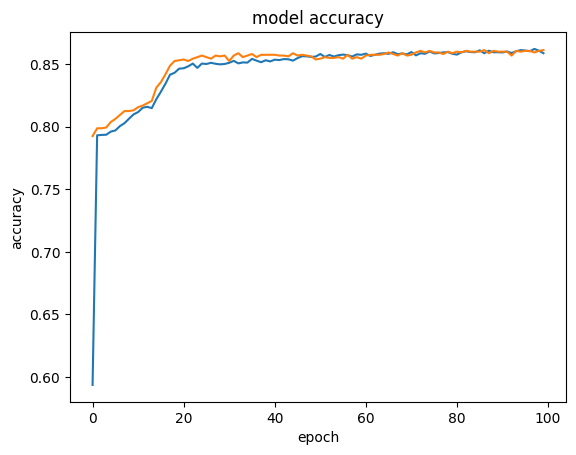

In [87]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

In [88]:
import plotly.graph_objects as go

epochs = range(1, len(history.history['accuracy']) + 1)

fig = go.Figure()

fig.add_trace(go.Scatter(x=list(epochs), y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig.add_trace(go.Scatter(x=list(epochs), y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))

fig.update_layout(
    title='Model Accuracy Over Epochs',
    xaxis_title='Epoch',
    yaxis_title='Accuracy',
    hovermode='x unified'
)

fig.show()

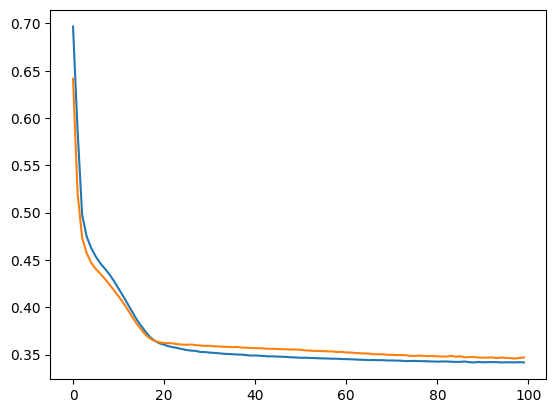

In [89]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


In [90]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


#undersampling

In [91]:
from imblearn.under_sampling import RandomUnderSampler
X_train1,X_test1,y_train1,y_test1=train_test_split(X,Y,test_size=0.2,random_state=42)

In [92]:
res=RandomUnderSampler(random_state=42)
X_resampled,y_resampled=res.fit_resample(X_train1,y_train1)

In [93]:
y_train1.shape

(8000,)

In [94]:
y_resampled.value_counts()

,count
Exited,
0,1644
1,1644


#OVERSAMPLING

In [95]:
from imblearn.over_sampling import RandomOverSampler
X_train2,X_test2,y_train2,y_test2=train_test_split(X,Y,test_size=0.2,random_state=42)

In [96]:
r2=RandomOverSampler(random_state=42)
X_res,y_res=r2.fit_resample(X_train2,y_train2)

In [97]:
y_res.value_counts()

,count
Exited,
0,6356
1,6356


#main disadvantage as duplicate of data model may consider it important and may cause overfitting

#smote(synthetic minority over sampling technique)
if we generate new datapoints without duplication
uses interpolation we generate a new data point between two existing datapoints

In [98]:
from imblearn.over_sampling import SMOTE
X_train3,X_test3,y_train3,y_test3=train_test_split(X,Y,test_size=0.2,random_state=42)

In [99]:
smote=SMOTE(random_state=42)

X_res2,y_res2=smote.fit_resample(X_train3,y_train3)

In [100]:
y_res2.value_counts()

,count
Exited,
0,6356
1,6356


#for ensemble learning use balanced random forest classifier

In [122]:
from sklearn.linear_model import LogisticRegression

#class weights techniques
model4=LogisticRegression(class_weight={0:1,1:1.6})
model4.fit(X_train,y_train)

LogisticRegression(class_weight={0: 1, 1: 1.6})

In [123]:
y_pred=model4.predict(X_test)
accuracy_score(y_test,y_pred)

0.8145

🔥 What is a ROC Curve?

ROC = Receiver Operating Characteristic curve

👉 It shows how well your model separates classes (0 vs 1) across all thresholds

🔹 Axes (very important)
X-axis → False Positive Rate (FPR)
Y-axis → True Positive Rate (TPR)
Formulas:
TPR (Recall) = TP / (TP + FN)
FPR = FP / (FP + TN)
🔥 Why do we need it?

Your model outputs probabilities, like:

0.2, 0.6, 0.8, 0.3...

To convert into class (0 or 1), you choose a threshold:

Threshold = 0.5 → default
But what if we change it?

👉 ROC shows performance at ALL thresholds (0 → 1)

🔁 How ROC is built (intuition)

Imagine you vary threshold:

Threshold	What happens
0.9	Very strict → few positives
0.5	balanced
0.1	very loose → many positives

For each threshold:

Calculate TPR
Calculate FPR
Plot point

👉 Join all points → ROC curve

🧠 Intuition (THIS is the key)

Think like this:

ROC shows how good your model is at ranking positives above negatives

🔥 Ideal vs Bad model
✅ Perfect model
Goes straight up → then right
TPR = 1, FPR = 0
❌ Random model
Diagonal line

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


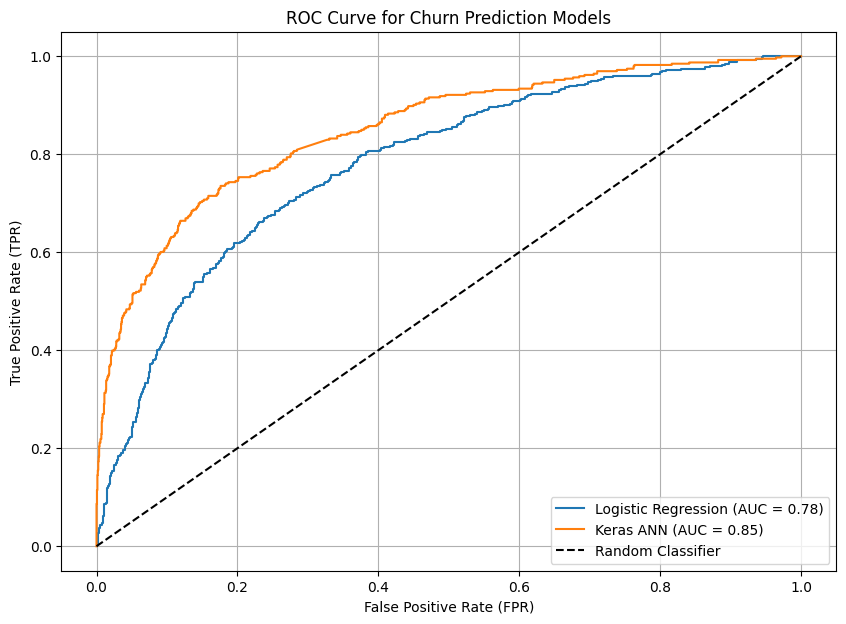

In [124]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predictions for Logistic Regression (model4)
y_pred_proba_model4 = model4.predict_proba(X_test)[:, 1]
fpr_model4, tpr_model4, thresholds_model4 = roc_curve(y_test, y_pred_proba_model4)
auc_model4 = roc_auc_score(y_test, y_pred_proba_model4)

# Predictions for Keras ANN (model)
y_pred_proba_model = model.predict(X_test)
fpr_model, tpr_model, thresholds_model = roc_curve(y_test, y_pred_proba_model)
auc_model = roc_auc_score(y_test, y_pred_proba_model)

# Plotting the ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_model4, tpr_model4, label=f'Logistic Regression (AUC = {auc_model4:.2f})')
plt.plot(fpr_model, tpr_model, label=f'Keras ANN (AUC = {auc_model:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Dashed diagonal line

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Churn Prediction Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

🧠 Real meaning (MOST IMPORTANT)
(area under roc curve)
AUC = probability that model ek random positive ko
ek random negative se upar rank kare

🔥 Example:

AUC = 0.85 means:

👉 85% chance hai ki:

churn customer ko higher score milega
non-churn se
💥 Ek line me yaad rakh

AUC jitna bada → model utna better at separating classes

🧠 1) “Elbow (bend)” ≈ FPR 0.2–0.3, TPR 0.75–0.85 — kyon?

ROC curve pe tum 3 zones dekhte ho:

Left (start) → thoda move karo, TPR bahut fast badhta, FPR kam badhta
Middle (bend/elbow) → TPR ab bhi badh raha, par speed slow hone lagti
Right (flat) → TPR almost 1, par FPR tez badhta (zyada galti)

👉 “Best balance” wahi hota hai jahan:

curve sharp se smooth hota hai (diminishing returns start)
ya mathematically: TPR − FPR maximum hota hai

Tumhare plot me wo bend roughly wahi area me dikhta hai:

FPR ~ 0.2–0.3
TPR ~ 0.75–0.85

Why?
Kyunki us point ke baad:

TPR thoda hi badhega
par FPR kaafi badh jayega
👉 yani extra gain kam, cost zyada
🧠 2) “Threshold ≈ 0.3–0.5” — ye kaise pata?

Important truth:

ROC graph threshold dikhata hi nahi — bas (FPR, TPR) points dikhata hai.

Threshold ka relation aise hai:

High threshold (0.7–0.9) → left side (strict)
Medium (0.3–0.5) → middle (balanced)
Low (0.1–0.2) → right side (loose)

👉 Kyun?

Threshold kam → zyada log “positive” → TPR ↑ but FPR bhi ↑ (right shift)
Threshold zyada → kam log positive → TPR ↓ but FPR ↓ (left shift)

Isliye:

Jo middle-left elbow point hai → wo generally mid thresholds (≈0.3–0.5) se aata hai